# https://docs.os.uk/os-downloads/products/water-portfolio/os-open-rivers

In [1]:
import geopandas as gpd
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt

rivers_route_file = "../data/oprvrs_gpkg_gb/Data/oprvrs_gb.gpkg"

counties_file = "../data/bdline_gpkg_gb/Data/bdline_gb.gpkg"

In [9]:
# Load the county boundaries
high_water = gpd.read_file(counties_file, layer="high_water")

counties = gpd.read_file(counties_file, layer="boundary_line_historic_counties")

# display(gpd.list_layers(counties_file))

In [ ]:
nodes = gpd.read_file(rivers_route_file, layer="hydro_node")

links = gpd.read_file(rivers_route_file, layer="watercourse_link")

,name,geometry_type
0,hydro_node,Point
1,watercourse_link,LineString


In [47]:
links

,id,flow_direction,length,fictitious,form,watercourse_name,watercourse_name_alternative,start_node,end_node,geometry
0,CBB29128-E3D9-41DC-B42D-C897B91BC798,in direction,698.0,0,inlandRiver,NaN,NaN,EEB098C2-0A0E-43CD-8412-4934607F27BC,47BE35B6-7896-40ED-BD09-1E5268B934BB,"LINESTRING (464870.89 1213066.83, 464803.34 12..."
1,A9DE91C2-3E83-4CB0-8054-A67D58B250F3,in direction,1638.0,0,inlandRiver,Burn of Skaw,NaN,EEBA1BA4-EB4F-4F7B-8F23-6F12439C0D72,6CCA1E9F-C1B5-4779-9F82-225CA799EB59,"LINESTRING (464604.98 1216285.95, 464623.92 12..."
2,2BA5B04B-0E80-435A-8FEE-BD1AE04B033B,in direction,88.0,0,inlandRiver,NaN,NaN,AB52C15B-AD0E-4241-B4F9-EC56D89BF228,BF7D6801-67F9-4361-9819-C3DF559CF72C,"LINESTRING (464702.95 1214013.85, 464663.95 12..."
3,F6B7A545-A959-488C-8145-1ED951A40FF7,in direction,559.0,0,inlandRiver,Burn of Norwick,NaN,BF7D6801-67F9-4361-9819-C3DF559CF72C,4E41746F-D1E3-4D1C-B2EC-85177FDDD967,"LINESTRING (464632.76 1214060.7, 464657.26 121..."
4,8EC680EF-3C36-4C57-946F-7868FC06A035,in direction,96.0,0,inlandRiver,NaN,NaN,A23D8A47-32E5-499A-8820-EEE2716F4D13,4E41746F-D1E3-4D1C-B2EC-85177FDDD967,"LINESTRING (464782.25 1214486.58, 464876.25 12..."
...,...,...,...,...,...,...,...,...,...,...
193035,5CEB28DA-2FB6-430B-9ECC-136EC390B18B,in direction,232.0,0,inlandRiver,NaN,NaN,350FB812-C546-45EF-AB20-750F59F5A5FF,46FF6485-71DA-468D-97E3-27E0740BE5B8,"LINESTRING (142067.43 33538.46, 142050.77 3352..."
193036,DB7D9A1C-2451-4E3C-AA6A-88DAFD69F02E,in direction,732.0,0,inlandRiver,NaN,NaN,6707A242-4329-44E0-9E7C-B4507A80B796,9B3545A0-5385-4A55-9951-FF35DAB13C3C,"LINESTRING (145424.72 35748.27, 145428.69 3571..."
193037,540E6D0B-36A4-4E5C-BF7B-B64B94113F7D,in direction,568.0,0,inlandRiver,NaN,NaN,9F8D5AA3-6A1C-4E6F-A11A-DF2A23EFAA02,4844ACBC-A80F-4E3E-B356-3406EBDFDA76,"LINESTRING (139378.67 35449.55, 139335.43 3551..."
193038,85AE135D-AF25-4F52-86B0-D52916F62FF2,in direction,733.0,0,inlandRiver,NaN,NaN,BB1A5624-43FB-405C-91C6-37FFBADBF7A0,48331820-E0B0-4B85-B626-BAD6A8FDBA65,"LINESTRING (143070.37 37026.09, 143047.38 3703..."


In [34]:
links[links["watercourse_name"].str.contains("River")]["watercourse_name"].unique()

<StringArray>
[         'River Burn',        'River Thurso',          'River Hope',
     'Halladale River',        'River Borgie',         'River Naver',
       'River Falloch',       'River Strathy',       'Kinloch River',
    'Strathmore River',
 ...
        'Carnon River',       'River Kennall',       'Helford River',
         'River Cober',     'Angarrack River',         'River Hayle',
      'Stennack River',      'Penberth River', 'Newlyn Coombe River',
     'Larriggan River']
Length: 1199, dtype: str

<Axes: >

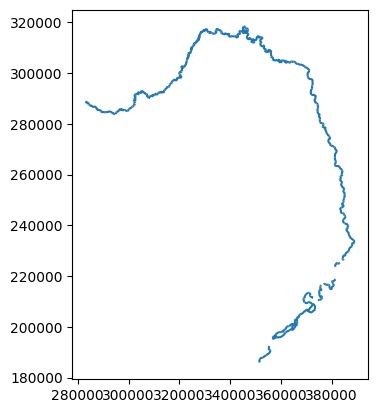

In [43]:
river_name = "River Severn"
links[links["watercourse_name_alternative"].str.contains(river_name) | links["watercourse_name"].str.contains(river_name)].plot()

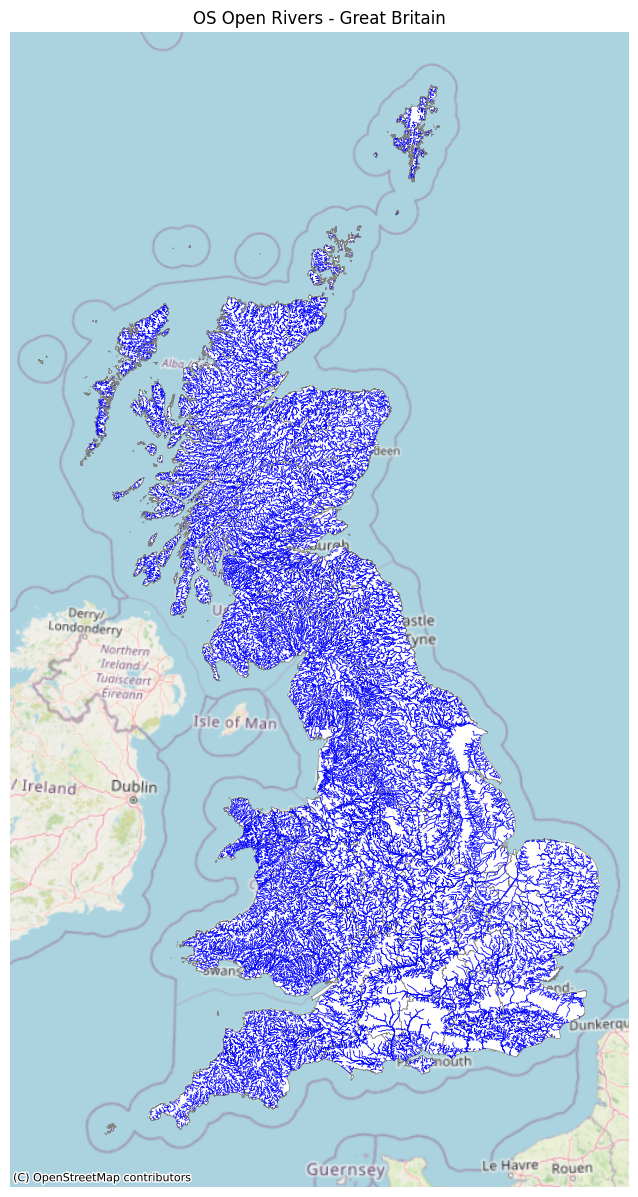

In [5]:
fig, ax = plt.subplots(figsize=(10, 15))

counties.plot(ax=ax, linewidth=0.5, color='white', edgecolor='grey')
links.plot(ax=ax, linewidth=0.5, color='blue')

ctx.add_basemap(ax, crs=counties.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Clean up the plot
ax.set_title("OS Open Rivers - Great Britain")
ax.set_axis_off()
plt.show()

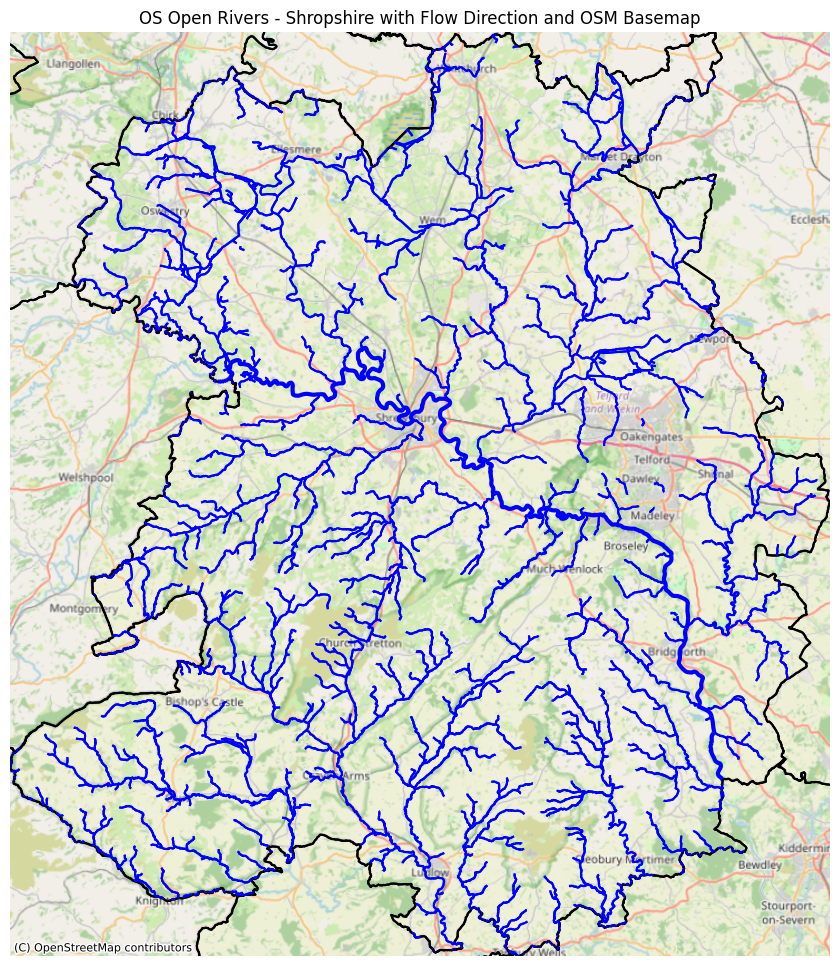

In [ ]:
import numpy as np
import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 12))

# Get the Shropshire geometry
shropshire = counties[counties["Name"] == "Shropshire"]

# Get the bounding box of Shropshire to set extent
minx, miny, maxx, maxy = shropshire.total_bounds

# Clip rivers to exactly the Shropshire boundary (rather than the bounding box)
shropshire_rivers = links.clip(shropshire)

# Plot counties and rivers
counties.plot(ax=ax, linewidth=1.5, facecolor='none', edgecolor='black')

river_name = "River Severn"
severn_mask = shropshire_rivers["watercourse_name_alternative"].str.contains(river_name) | shropshire_rivers["watercourse_name"].str.contains(river_name)
severn = shropshire_rivers[severn_mask]
other_rivers = shropshire_rivers[~severn_mask]

other_rivers.plot(ax=ax, linewidth=1.5, color='blue')
severn.plot(ax=ax, linewidth=3.0, color='blue', zorder=5)

shropshire_rivers.plot(ax=ax, linewidth=1.5, color='blue')

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add OSM basemap
ctx.add_basemap(ax, crs=counties.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

ax.set_title("OS Open Rivers - Shropshire with Flow Direction and OSM Basemap")
ax.set_axis_off()
plt.show()

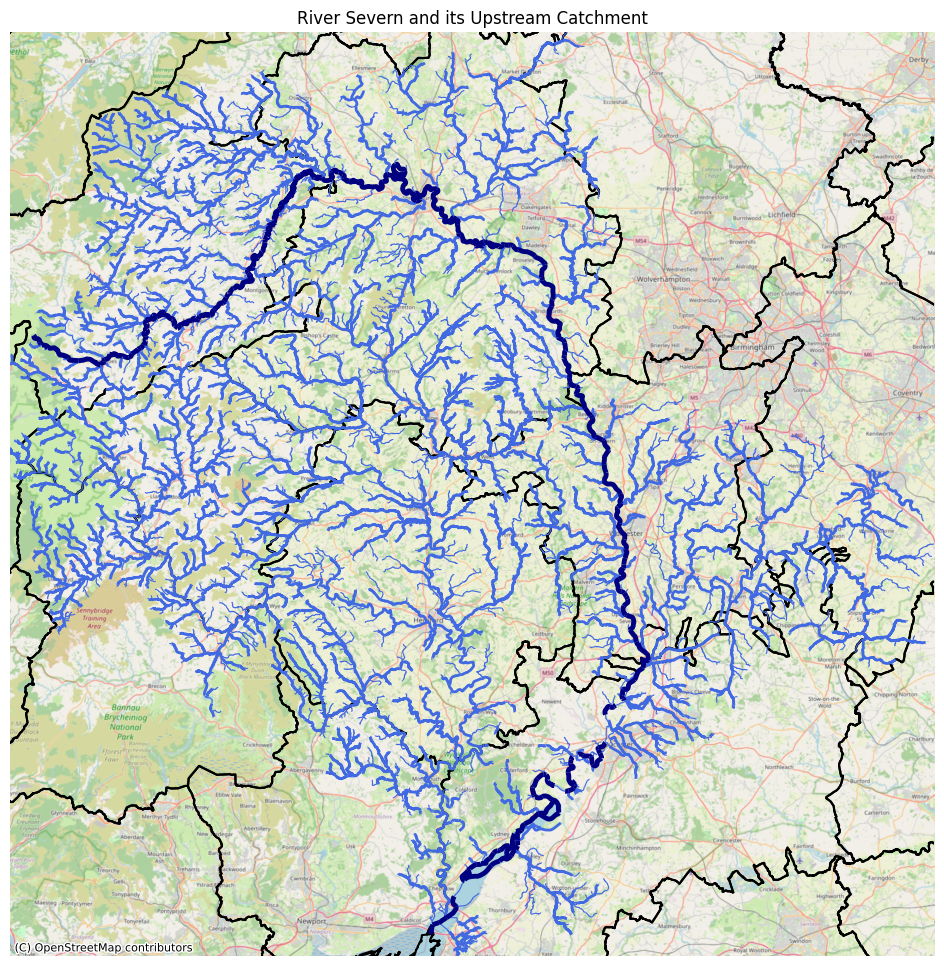

In [58]:
import networkx as nx

# Create a directed graph mapping nodes upstream
G = nx.DiGraph()
edges = []

for idx, row in links.iterrows():
    u = row['start_node']
    v = row['end_node']
                
    # If the flow direction is reversed, normal flow is v -> u, so upstream is u -> v.
    # Otherwise normal flow is u -> v, so upstream is v -> u.
    if str(row['flow_direction']).lower() == 'in opposite direction':
        edges.append((u, v))
    else:
        edges.append((v, u))

G.add_edges_from(edges)

# Find River Severn segments
severn_mask = links["watercourse_name_alternative"] == "River Severn"
severn_segments = links[severn_mask]

# Find all nodes upstream of any point on the Severn
upstream_nodes = set()
for _, row in severn_segments.iterrows():
    u, v = row['start_node'], row['end_node']
    upstream_nodes.update([u, v])
    if u in G: upstream_nodes.update(nx.descendants(G, u))
    if v in G: upstream_nodes.update(nx.descendants(G, v))

# Filter to get the catchment (segments where at least one node is in our upstream set)
def is_upstream(row):
    return row['start_node'] in upstream_nodes or row['end_node'] in upstream_nodes

severn_catchment = links[links.apply(is_upstream, axis=1)]

# Separate the catchment into three classes for styling
is_severn = (severn_catchment["watercourse_name_alternative"].str.contains('Severn', case=False, na=False) | 
             severn_catchment["watercourse_name"].str.contains('Severn', case=False, na=False))
is_named = (severn_catchment["watercourse_name"].notna() | 
            severn_catchment["watercourse_name_alternative"].notna()) & ~is_severn
is_unnamed = ~(is_severn | is_named)

severn_only = severn_catchment[is_severn]
named_rivers = severn_catchment[is_named]
unnamed_rivers = severn_catchment[is_unnamed]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))
minx, miny, maxx, maxy = severn_catchment.total_bounds

counties.plot(ax=ax, linewidth=1.5, facecolor='none', edgecolor='black')

# Plot from bottom to top (thinnest to thickest)
if not unnamed_rivers.empty:
    unnamed_rivers.plot(ax=ax, linewidth=0.8, color='royalblue', zorder=2)
if not named_rivers.empty:
    named_rivers.plot(ax=ax, linewidth=2, color='royalblue', zorder=3)
if not severn_only.empty:
    severn_only.plot(ax=ax, linewidth=3.5, color='navy', zorder=4)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

try:
    ctx.add_basemap(ax, crs=counties.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
except Exception as e:
    print("Could not add basemap:", e)

ax.set_title("River Severn and its Upstream Catchment")
ax.set_axis_off()
plt.show()

AttributeError: 'DiGraph' object has no attribute 'plot'